# XGBoost + WCG

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor
import warnings
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [36]:
# 读取数据并合并
train = pd.read_csv('../titanic/train.csv')
test = pd.read_csv('../titanic/test.csv')
test['Survived'] = np.nan

truth = pd.read_csv('../titanic/truth.csv')

data = pd.concat([train, test], ignore_index=True, sort=False)

构造Title字段

In [37]:
data['Title'] = 'man'
data.loc[data['Name'].str.contains('Master', na=False),'Title'] = 'boy'
data.loc[data['Sex']=='female','Title'] = 'woman'

具有缺失值的特征：Age, Fare, Cabin, Embarked

用回归树填补Age和Fare

In [38]:
data['Title_Encode'] = data['Title'].map({'man':0,'woman':1,'boy':2})
data['Embarked'].fillna('S', inplace=True)
data['Embarked_code'] = data['Embarked'].map({'C':0,'Q':1,'S':2})
data['Sex_code'] = data['Sex'].map({'male':0,'female':1})

In [39]:
null_index=  data[data['Age'].isnull()].index

In [40]:
def impute_with_tree(df, target, features):
    df = df.copy()

    # 用中位数进行填充
    for f in features:
        if df[f].isnull().any():
            df[f] = df[f].fillna(df[f].median())
    x_train = df[df[target].notnull()][features]
    x_test = df[df[target].isnull()][features]
    if len(x_test) == 0:
        return df[target]
    y_train = df[df[target].notnull()][target]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(x_train, y_train)
    df.loc[df[target].isnull(), target]  = model.predict(x_test)
    return df[target]

data['Age'] = impute_with_tree(data, 'Age', ['Title_Encode', 'Parch','SibSp','Pclass'])

# 填 Fare：用 Title_code, Pclass, Embarked_code, Sex_code, Age
data['Fare'] = impute_with_tree(data, 'Fare', ['Title_Encode','Pclass','Embarked_code','Sex_code','Age'])

In [41]:
data.loc[null_index, 'Age']

5       28.486328
17      32.626214
19      24.093750
26      28.486328
28      24.093750
          ...    
1299    24.093750
1301    24.093750
1304    28.486328
1307    28.486328
1308     5.892857
Name: Age, Length: 263, dtype: float64

In [42]:
data['Ticket_clean'] = data['Ticket'].astype(str).str.strip()
data['TicketFreq'] = data.groupby('Ticket_clean')['Ticket_clean'].transform('count')

# FareAdj = Fare / TicketFreq
data['FareAdj'] = data['Fare'] / data['TicketFreq']

In [43]:

data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [44]:
# 筛选训练集中的成年男性
train_male = data[(data['PassengerId']<=891)&(data['Title']=='man')]
train_male['x1'] = train_male['Fare']/(train_male['TicketFreq']*10)
train_male['x2'] = train_male['FamilySize'] + train_male['Age'] / 70.0

test_male = data[(data['PassengerId']>891)&(data['Title']=='man')]
test_male['x1'] = test_male['Fare']/(test_male['TicketFreq']*10)
test_male['x2'] = test_male['FamilySize'] + test_male['Age'] / 70.0

y_test = truth.loc[truth['PassengerId'].isin(test_male['PassengerId']), 'Survived']

In [45]:
train_data = pd.DataFrame(
    {
        'y': train_male['Survived'],
        'x1': train_male['x1'],
        'x2': train_male['x2'],
        'Pclass': train_male['Pclass']
    }
)
train_data.reset_index(drop=True, inplace=True)

test_data = pd.DataFrame(
    {
        'x1': test_male['x1'],
        'x2': test_male['x2'],
        'Pclass': test_male['Pclass']
    }
)
test_data.reset_index(drop=True, inplace=True)

In [46]:

from matplotlib.colors import ListedColormap
# XGBoost 参数
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'error',
    'max_depth': 5,
    'eta': 0.1,
    'gamma': 0.1,
    'colsample_bytree': 1,
    'min_child_weight': 1
}

In [47]:
# XGBoost Classifier
X_train,y_train = train_data.drop(['y','Pclass'], axis=1),train_data['y']
x_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='error',
    max_depth=5,
    learning_rate=0.1,   # 对应 eta
    gamma=0.1,
    colsample_bytree=1,
    min_child_weight=1,
    n_estimators=500,
    use_label_encoder=False,
    random_state=42
)

x_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'error'


In [48]:
X_train

,x1,x2
0,0.725000,2.314286
1,0.805000,1.500000
2,0.845830,1.406948
3,2.593125,1.771429
4,0.805000,1.285714
...,...,...
532,1.050000,1.400000
533,0.705000,1.357143
534,1.300000,1.385714
535,3.000000,1.371429


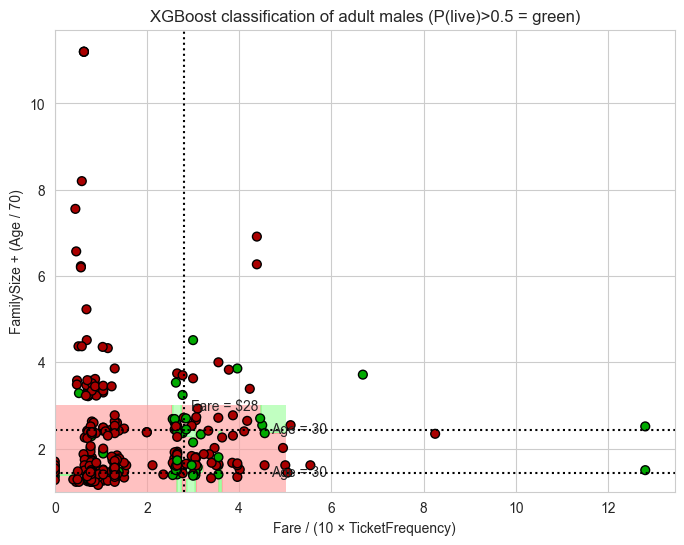

In [49]:
# 网格点
x1s = np.linspace(0, 5, 100)
x2s = np.linspace(1, 3, 100)
xx1, xx2 = np.meshgrid(x1s, x2s)
grid = np.c_[xx1.ravel(), xx2.ravel()]

# 预测生存概率（第二列是 p(y=1)）
p = x_model.predict_proba(grid)[:, 1]

# 转换为 0/1 分类结果
Z = (p > 0.5).astype(int).reshape(xx1.shape)

# 绘制决策边界
plt.figure(figsize=(8,6))
cmap_bg = ListedColormap(['#FF9999','#99FF99'])

# 分类区域
plt.contourf(xx1, xx2, Z, cmap=cmap_bg, alpha=0.6)

# 样本点
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1], c=y_train, edgecolor='k', cmap=ListedColormap(['#AA0000','#00AA00']), s=40)

# 参考线
plt.axvline(x=2.8, linestyle='dotted', color='black')
plt.axhline(y=1.43, linestyle='dotted', color='black')
plt.axhline(y=2.43, linestyle='dotted', color='black')

# 标注
plt.text(2.95,2.9,'Fare = $28')
plt.text(4.7,2.35,'Age = 30')
plt.text(4.7,1.35,'Age = 30')

plt.xlabel("Fare / (10 × TicketFrequency)")
plt.ylabel("FamilySize + (Age / 70)")
plt.title("XGBoost classification of adult males (P(live)>0.5 = green)")
plt.show()

In [50]:
# 固定随机种子
np.random.seed(300)

# 随机划分数据集
idx = np.arange(537)
s = np.random.choice(idx, size=100, replace=False)   # 测试集索引
s2 = np.setdiff1d(idx, s)  # 训练集索引

In [51]:
# 训练 XGBoost 模型（只用 x1, x2）
from sklearn.metrics import roc_curve, auc
model = XGBClassifier(
    n_estimators=500,
    use_label_encoder=False,
    eval_metric="logloss"
)
model.fit(train_data.loc[s2, ['x1', 'x2']], train_data.loc[s2, 'y'])

# 在测试集上预测概率
p = model.predict_proba(train_data.loc[s, ['x1', 'x2']])[:, 1]

fpr, tpr, thresholds = roc_curve(train_data.loc[s, 'y'], p)
auc = auc(fpr, tpr)
print(f"AUC: {auc}")


AUC: 0.6777777777777777


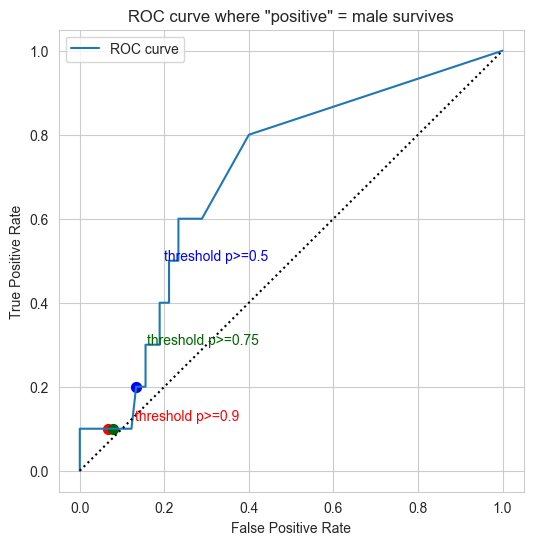

Area under ROC = 0.765556


In [52]:

# 构建 ROC DataFrame
roc = pd.DataFrame({
    'TN': np.zeros(102),
    'FP': np.zeros(102),
    'FN': np.zeros(102),
    'TP': np.zeros(102),
    'FPR': np.zeros(102),
    'TPR': np.zeros(102)
}, index=np.round(np.linspace(0, 1.01, 102), 2))

# 循环不同阈值
y_true = train_data.loc[s, 'y'].values
for i, thresh in enumerate(np.linspace(0, 1, 102)):
    y_pred = (p >= thresh).astype(int)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    roc.iloc[i] = [TN, FP, FN, TP,
                   FP / (FP + TN) if (FP + TN) > 0 else 0,
                   TP / (TP + FN) if (TP + FN) > 0 else 0]

# 对角线
diag = pd.DataFrame({'x': [0, 1], 'y': [0, 1]})

# 画 ROC 曲线
plt.figure(figsize=(6,6))
plt.plot(roc["FPR"], roc["TPR"], label="ROC curve")
plt.plot(diag.x, diag.y, linestyle="dotted", color="black")

# 标注几个阈值
plt.scatter(roc.iloc[91].FPR, roc.iloc[91].TPR, c="red", s=50)
plt.text(0.13, 0.12, "threshold p>=0.9", color="red")

plt.scatter(roc.iloc[76].FPR, roc.iloc[76].TPR, c="darkgreen", s=50)
plt.text(0.16, 0.30, "threshold p>=0.75", color="darkgreen")

plt.scatter(roc.iloc[51].FPR, roc.iloc[51].TPR, c="blue", s=50)
plt.text(0.20, 0.50, "threshold p>=0.5", color="blue")

plt.title('ROC curve where "positive" = male survives')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 计算 AUC（近似梯形积分）
area = 0
for i in range(101):
    area += roc.TPR.iloc[i] * (roc.FPR.iloc[i] - roc.FPR.iloc[i+1])
print(f"Area under ROC = {area:.6f}")

In [53]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# 设置随机数种子（等价于 R 里的 set.seed(2)）
np.random.seed(2)

def hybrid_gender_xgb_cv(train_df, trials=100, sample_size=800, threshold=0.90):
    """
    复现 R 代码在 Python 中的流程：
    - 在数据集中随机抽取 sample_size 行作为训练集，其余作为测试集
    - 基线模型：女性全部预测为幸存（1），男性默认死亡（0）
    - 针对成年男性子集，在训练集上用 XGBoost 训练（使用特征 x1, x2）
    - 在男性测试集上进行预测，概率大于 threshold 时预测为幸存
    - 将男性预测结果和女性基线预测结果合并，计算测试集整体的准确率
    - 重复 trials 次，返回平均准确率和每次试验的准确率
    """

    n = train_df.shape[0]  # 数据集总行数
    # 检查样本数是否合理，防止抽样过大
    if sample_size >= n:
        raise ValueError("sample_size 必须小于数据集的行数")

    trial_accuracies = []  # 存储每次试验的准确率

    # 在整个数据集上预先计算两个特征（和 R 代码一致）
    # x1 = FareAdj / 10, 票价缩放
    # x2 = FamilySize + Age/70, 家庭规模 + 年龄缩放
    train = train_df.copy()
    train['x1'] = train['FareAdj'] / 10.0
    train['x2'] = train['FamilySize'] + train['Age'] / 70.0

    # 多次重复随机抽样试验
    for t in range(trials):
        # 随机抽取 sample_size 个索引作为训练集，其余作为测试集
        sampled_idx = np.random.choice(train.index.values, size=sample_size, replace=False)
        test_idx = np.setdiff1d(train.index.values, sampled_idx)

        # 从训练集里取男性数据
        dataB = train.loc[sampled_idx]
        dataB_males = dataB[dataB['Title'] == 'man'].copy()

        # 从测试集里取男性数据
        dataC = train.loc[test_idx]
        dataC_males = dataC[dataC['Title'] == 'man'].copy()

        # 基线预测：默认全体为 0（死亡），再把女性设为 1（幸存）
        predict_all = pd.Series(0, index=train.index)
        predict_all.loc[train['Sex'] == 'female'] = 1

        # 如果训练集中没有男性（极少情况），直接退化为基线模型
        if dataB_males.shape[0] == 0:
            acc = (predict_all.loc[test_idx] == train.loc[test_idx, 'Survived']).mean()
            trial_accuracies.append(acc)
            continue

        # 用男性训练集训练 XGBoost 模型
        model = XGBClassifier(
            objective='binary:logistic',  # 二分类逻辑回归
            use_label_encoder=False,      # 不使用过时的 label encoder
            eval_metric='error',          # 评估指标：错误率
            max_depth=5,                  # 树深度
            learning_rate=0.1,            # 学习率
            gamma=0.1,                    # 正则化参数 gamma
            colsample_bytree=1,           # 每棵树的特征采样比例
            min_child_weight=1,           # 叶子节点最小权重
            n_estimators=500,             # 树的数量
            random_state=42                # 随机种子
        )

        # 训练数据（男性训练集上的 x1, x2 特征）
        X_train = dataB_males[['x1', 'x2']].values
        y_train = dataB_males['Survived'].astype(int).values
        model.fit(X_train, y_train)

        # 在男性测试集上预测
        if dataC_males.shape[0] > 0:
            X_test = dataC_males[['x1', 'x2']].values
            p = model.predict_proba(X_test)[:, 1]  # 预测概率（存活的概率）
            preds_male = (p >= threshold).astype(int)  # 大于阈值就判定为幸存（1）

            # 把男性的预测结果填回全体预测结果
            predict_all.loc[dataC_males.index] = preds_male

        # 在整个测试集（test_idx）上计算准确率
        y_true = train.loc[test_idx, 'Survived']  # 测试集真实标签
        valid_mask = ~y_true.isna()               # 去掉缺失值
        if valid_mask.sum() == 0:
            continue

        # sm = 预测错误的数量
        sm = np.abs(predict_all.loc[test_idx[valid_mask]] - y_true[valid_mask]).sum()
        acc = 1.0 - sm / valid_mask.sum()  # 准确率 = 1 - 错误率
        trial_accuracies.append(acc)

    # 所有 trial 的平均准确率
    avg_acc = np.mean(trial_accuracies)
    return avg_acc, trial_accuracies

# 使用示例：
avg, trials_list = hybrid_gender_xgb_cv(data[(data['PassengerId']<=891)], trials=100, sample_size=800, threshold=0.90)
print("平均交叉验证准确率:", avg)

平均交叉验证准确率: 0.7881318681318679


In [54]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Title_Encode,Embarked_code,Sex_code,Ticket_clean,TicketFreq,FareAdj,FamilySize
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,man,0,2,0,A/5 21171,1,7.250000,2
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,woman,1,0,1,PC 17599,2,35.641650,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,woman,1,2,1,STON/O2. 3101282,1,7.925000,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,woman,1,2,1,113803,2,26.550000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,man,0,2,0,373450,1,8.050000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,28.486328,0,0,A.5. 3236,8.0500,NaN,S,man,0,2,0,A.5. 3236,1,8.050000,1
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,woman,1,0,1,PC 17758,3,36.300000,1
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,man,0,2,0,SOTON/O.Q. 3101262,1,7.250000,1
1307,1308,NaN,3,"Ware, Mr. Frederick",male,28.486328,0,0,359309,8.0500,NaN,S,man,0,2,0,359309,1,8.050000,1


In [63]:
model = XGBClassifier(
            objective='binary:logistic',  # 二分类逻辑回归
            use_label_encoder=False,      # 不使用过时的 label encoder
            eval_metric='error',          # 评估指标：错误率
            max_depth=5,                  # 树深度
            learning_rate=0.1,            # 学习率
            gamma=10,                    # 正则化参数 gamma
            colsample_bytree=1,           # 每棵树的特征采样比例
            min_child_weight=1,           # 叶子节点最小权重
            n_estimators=500,             # 树的数量
            random_state=2                # 随机种子
        )
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'error'


In [64]:
from sklearn.metrics import accuracy_score
pred = model.predict(test_data.loc[:,['x1', 'x2']])
accuracy_score(y_test, pred)

0.8204081632653061